## Paqueterías 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Implementación Regresión Lineal

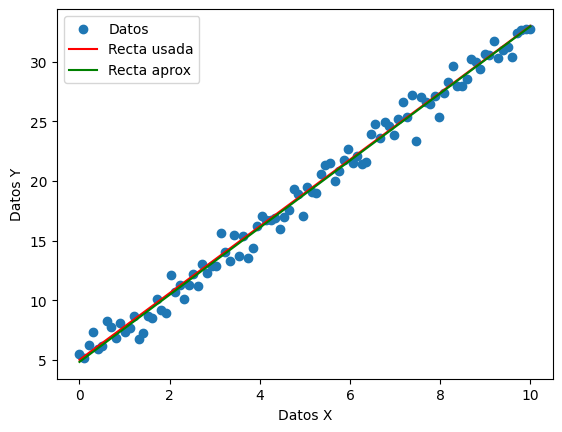

In [2]:
#Semilla para generar datos aleatorios
np.random.seed(42)

def genera_datos(n, beta, alfa, desviacion):
  x=np.linspace(0,10,n)
  y=alfa+beta*x+np.random.normal(0,desviacion,n)
  return x, y

n_puntos=100
pendiente=2.8
corte=5
ds=1 #Dispersión de los datos

x,y=genera_datos(n_puntos, pendiente, corte, ds)

#Calculo de los parámetros
# Alfa
beta=(n_puntos*sum(x*y)-sum(x)*sum(y))/(n_puntos*sum(x*x)-sum(x)**2)
beta

# Beta
alfa=(sum(y)*sum(x*x)-sum(x)*sum(x*y))/(n_puntos*sum(x*x)-sum(x)**2)
alfa

plt.scatter(x,y, label="Datos")
plt.plot(x, corte+pendiente*x, color="red", label="Recta usada")
plt.plot(x, alfa+beta*x, color="green", label="Recta aprox")
plt.xlabel("Datos X")
plt.ylabel("Datos Y")
plt.legend()
plt.show()

## Implementacion de gradiente descendente con $\omega_0$ y $\omega_1$

Text(0, 0.5, 'Consumo')

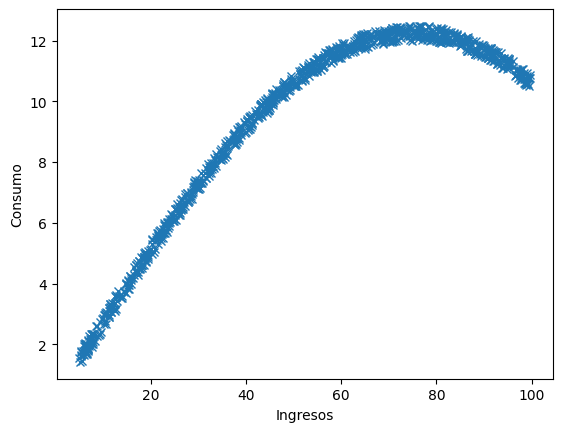

In [3]:
df = pd.read_excel('Datos.xlsx')
x = df['ingresos']
y = df['consumo']

plt.figure()
plt.plot(x,y,'x')
plt.xlabel('Ingresos')
plt.ylabel('Consumo')

In [4]:
#muestra el total de datos n = 1000
df.describe()

,ingresos,consumo
count,1000.000000,1000.000000
mean,52.557437,9.282316
std,27.407560,3.218789
min,5.010866,1.419883
25%,28.933787,7.055647
50%,53.212577,10.781619
75%,76.313770,11.838378
max,99.745671,12.482348


In [5]:
def grad(x, y, n, w_0, A, iter):
    # x = datos (ingresos)
    # y = taget(consumo)
    # n = numero de puntos
    # w_0 = pendiente inicial
    # A = learning rate
    # iter = número de iteraciones del gradiente descendente
        
    w = w_0  # Inicializamos la pendiente con el valor inicial w_0
    # Listas para almacenar los valores de w y de la función de costo en cada iteración
    w_val = []
    cost_val = []

    for i in range(iter):
        h = w * x  # Calculamos la predicción del modelo lineal
        error = h - y  # Error de la forma: (h - y)

        J = np.sum(error**2) / n # Definimos funcion de costo
        
        dj = 2 * np.sum(error * x) / n # Derivada de la función de costo con respecto a w

        w = w - A * dj # w(t+1) será la actualización del valor de w original con la formula vista en clase

        w_val.append(w) #Guardando valores de w y funcion de costo
        cost_val.append(J)

    return w, np.array(w_val), np.array(cost_val)  # Retorna valores para graficar

In [6]:
def coste(x,y,n,w_0,A,iter):
    nw = 100 #numero de omegas
    w_vector = np.linspace(0,0.3,nw) # Valores del parámetro la pendiente
    b = 0 # Valor de la intersección de la recta de regresión
    J = np.zeros(nw) # Reserva de espacio para el vector de costes
    for k in range(nw):
        w = w_vector[k]
        h = w*x + b # hipótesis
        error = h-y # error (h-y)
        J[k] = np.sum(error**2) / n # Coste para un determinado valor de w

    wmin, w_val, cost_val = grad(x, y, n, w_0, A, iter)
    print(wmin)

    plt.figure()
    plt.plot(w_vector,J)
    plt.plot(w_val, cost_val,'-',marker='.', markersize=4)
    plt.xlabel('Parámetro: w')
    plt.ylabel('Función de coste: J(w)')

Los valores a tener en cuenta en la función del Gradiente Descendente son
+ $n = 1000$
+ $w = 0.3$ (Inicializamos la pendiente con el valor inicial $w = w_0$
+ $A = α = 10^{-5}$
+ iter = 10000

In [7]:
grad(x, y, 1000, 0.3, 10**(-5), 100)

(np.float64(0.16119523477997785),
 array([0.29024169, 0.28116895, 0.2727336 , 0.26489087, 0.25759913,
        0.25081966, 0.24451648, 0.23865612, 0.23320747, 0.22814162,
        0.22343166, 0.2190526 , 0.21498118, 0.2111958 , 0.20767636,
        0.20440417, 0.20136187, 0.1985333 , 0.19590345, 0.19345836,
        0.19118505, 0.18907144, 0.18710633, 0.18527927, 0.18358057,
        0.18200121, 0.18053281, 0.17916757, 0.17789824, 0.17671809,
        0.17562085, 0.1746007 , 0.17365221, 0.17277036, 0.17195046,
        0.17118817, 0.17047943, 0.16982048, 0.16920782, 0.16863821,
        0.16810862, 0.16761623, 0.16715843, 0.16673279, 0.16633706,
        0.16596913, 0.16562705, 0.165309  , 0.1650133 , 0.16473837,
        0.16448275, 0.16424509, 0.16402413, 0.16381869, 0.16362769,
        0.1634501 , 0.16328499, 0.16313148, 0.16298876, 0.16285606,
        0.16273268, 0.16261798, 0.16251133, 0.16241217, 0.16231998,
        0.16223427, 0.16215457, 0.16208048, 0.16201159, 0.16194754,
        0.1618

0.16119523477997785


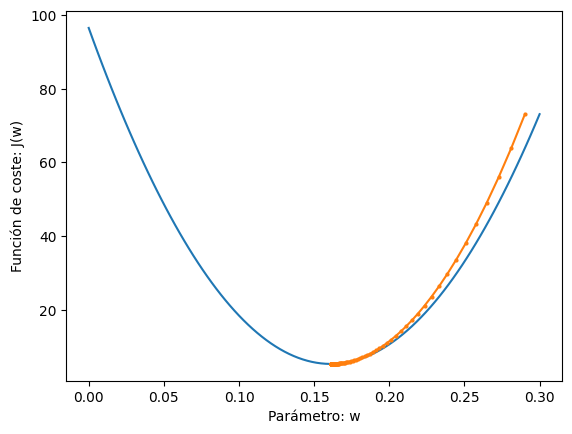

In [8]:
coste(x, y, 1000, 0.3, 10**(-5), 100)

In [9]:
grad(x, y, 1000, 0.3, 2.5*10**(-4), 100)

(np.float64(0.16109992719568972),
 array([0.05604235, 0.24056061, 0.10099954, 0.20655707, 0.12671825,
        0.18710464, 0.14143117, 0.17597646, 0.149848  , 0.16961036,
        0.15466303, 0.1659685 , 0.15741757, 0.1638851 , 0.15899336,
        0.16269324, 0.15989482, 0.16201142, 0.16041052, 0.16162136,
        0.16070554, 0.16139823, 0.16087431, 0.16127057, 0.16097086,
        0.16119755, 0.16102609, 0.16115577, 0.16105769, 0.16113188,
        0.16107576, 0.1611182 , 0.1610861 , 0.16111038, 0.16109202,
        0.16110591, 0.1610954 , 0.16110335, 0.16109734, 0.16110188,
        0.16109845, 0.16110105, 0.16109908, 0.16110057, 0.16109944,
        0.16110029, 0.16109965, 0.16110014, 0.16109977, 0.16110005,
        0.16109984, 0.1611    , 0.16109988, 0.16109997, 0.1610999 ,
        0.16109995, 0.16109991, 0.16109994, 0.16109992, 0.16109993,
        0.16109992, 0.16109993, 0.16109992, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.1610

0.16109992719568972


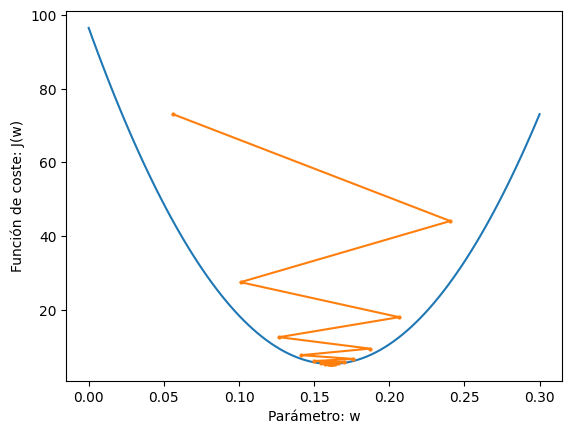

In [10]:
coste(x, y, 1000, 0.3, 2.5*10**(-4), 100)

In [11]:
grad(x, y, 1000, 0.3, 8*10**(-5), 100)

(np.float64(0.1610999271955862),
 array([0.22193355, 0.18774304, 0.17276872, 0.16621047, 0.16333818,
        0.16208021, 0.16152926, 0.16128796, 0.16118228, 0.16113599,
        0.16111572, 0.16110685, 0.16110296, 0.16110125, 0.16110051,
        0.16110018, 0.16110004, 0.16109998, 0.16109995, 0.16109994,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109993, 0.16109993, 0.16109993, 0.16109993, 0.16109993,
        0.16109

0.1610999271955862


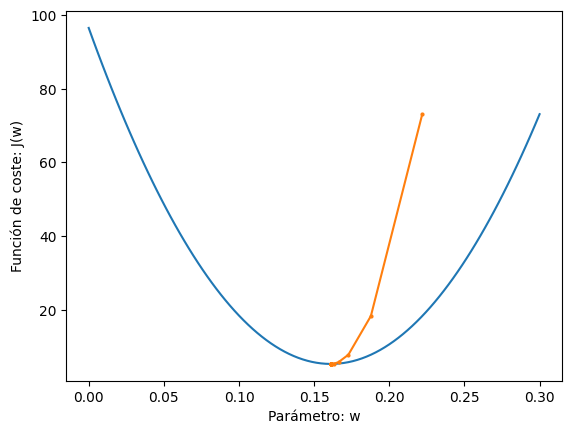

In [12]:
coste(x, y, 1000, 0.3, 8*10**(-5), 100)